In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## Importing required libraries

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split,DataLoader,TensorDataset

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Reading the data you are provided with

In [3]:
train=pd.read_csv("../input/digit-recognizer/train.csv")
test=pd.read_csv("../input/digit-recognizer/test.csv")

In [4]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Inspecting the datasets

In [6]:
len(train)

42000

In [7]:
len(test)

28000

In [8]:
train.shape

(42000, 785)

In [9]:
test.shape

(28000, 784)

## Defining predictors and target variable

In [10]:
# Target variable
labels=train.label


In [11]:
# Independent variables
train_ds=train.drop('label',axis=1)

In [12]:
train_ds.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Let's visualise the image and take a look at the label 

1


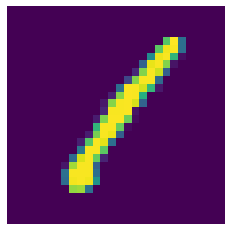

In [13]:
plt.imshow(train_ds[0:1].values.reshape(28,28))
plt.axis("off")
print(labels[0])

## Converting all kinds of data to numpy arrays

In [14]:
train_ds=train_ds.values
test_ds=test.values
labels=labels.to_numpy()             #labels was actually a pandas series


## Converting all kinds of data to Tensors

In [15]:
train_ds=torch.tensor(train_ds)
test_ds =torch.tensor(test_ds)
labels = torch.tensor(labels)

# Organising data into Tensordataset
 ***Each sample will be retrieved by indexing tensors along the first dimension.***

In [16]:
traiin_ds=TensorDataset(train_ds,labels)

In [17]:
traiin_ds[0:2]

(tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]),
 tensor([1, 0]))

## Splitting the Tensordataset into train and validation data

In [18]:
train_ds , val_ds = random_split(traiin_ds,(32000,10000))

In [19]:
# Define hyperparameters
batch_size = 150
learning_rate = 0.001

## Create batches

In [20]:
train_loader=DataLoader(train_ds , batch_size, shuffle = True)
val_loader=DataLoader(val_ds , batch_size, shuffle = False)


## Constructing the model

In [21]:
# for each image
input_size = 784
num_class = 10



In [22]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(nn.Linear(28*28 , 512),
                                    nn.ReLU(),
                                    nn.Linear(512 , 100),
                                    nn.ReLU(),
                                    nn.Linear(100 , 10))
        
        
    def forward(self,x):
        out = self.linear(x)
        return out

model = MnistModel()

## Define optimizer

In [23]:
opt      = torch.optim.Adam
opt = opt(model.parameters(),lr=learning_rate)

## Training the model using logistic regression

In [24]:
def fit(epochs,model,data):
    
    loss_fun = F.cross_entropy
    hist = []
    for Epoch in range(epochs):
        for img,label in data:
            out = model(img/255)
            loss = loss_fun(out,label)
            loss.backward()
            opt.step()
            opt.zero_grad()
            hist.append(loss)
        
        if (Epoch+1)%10 ==0:
            print(f"Epoch:[{Epoch+1}/{epochs}] ; Loss : {loss}")
    return hist
      

In [25]:
hist=fit(90,model,train_loader)

Epoch:[10/90] ; Loss : 0.07951617985963821
Epoch:[20/90] ; Loss : 0.00012574499123729765
Epoch:[30/90] ; Loss : 4.419620745466091e-05
Epoch:[40/90] ; Loss : 5.208398579270579e-05
Epoch:[50/90] ; Loss : 6.842406492069131e-06
Epoch:[60/90] ; Loss : 8.702216973688337e-07
Epoch:[70/90] ; Loss : 4.5537723281086073e-07
Epoch:[80/90] ; Loss : 3.075590200296574e-07
Epoch:[90/90] ; Loss : 9.298319270101274e-08


In [26]:
def acc(data):
    accuracy=[]
    for img , label in data:
        out = model(img/255)
        _,pred_index =torch.max(out,dim=1)
        x=torch.sum(pred_index==label)
        x=x/len(label)
        x=x*100
        accuracy.append(x)
    return np.mean(accuracy)
        
        

In [27]:
acc(val_loader)

97.85075

In [28]:
# plt.plot(hist, range(32100))

In [29]:
submission= pd.read_csv("../input/digit-recognizer/sample_submission.csv")
submission.head()

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [30]:
len(submission)


28000

In [31]:
def prediction(data):
    LABEL=[]
    
    out = model(data/255)
    out = F.softmax(out)     
    _,pred_index =torch.max(out,dim=1)
    LABEL.append(pred_index)   
    return LABEL

In [32]:
x=prediction(test_ds)
len(x[0])

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  """


28000

In [33]:
x=x[0].numpy()

In [34]:
submission["Label"]=x

In [35]:
submission.to_csv("submission.csv",index=False)

## DO UPVOTE !!